# Safe Reinforcement Learning with a Neural Safety Shield in GridWorld

**Author:** Zhihao Wu

## Project Overview

In this project, I build a safe reinforcement learning pipeline in a custom GridWorld environment.

The workflow combines:

* tabular Q-learning
* graph-based danger analysis
* supervised safety classification
* shield-guided action intervention

My main goal is to study how a learned safety shield changes exploration behaviour. I want to see whether the shield can reduce unsafe actions while still allowing the agent to learn useful policies.

I start by implementing and validating the GridWorld environment. I then train a baseline Q-learning agent, construct a danger map from hazard locations, build a labeled state-action dataset, train a neural safety shield, and integrate the shield back into the reinforcement learning loop.

The notebook also saves the main generated artefacts, including Q-tables, model files, datasets, logs, metrics, plots, and a project archive. This makes the results easier to inspect after the full workflow has been run.

## Notebook Structure

### Part 1: Notebook Setup and Shared Utilities

I prepare the shared imports, reproducibility controls, directory structure, timing utilities, smoothing functions, plotting helpers, and runtime checks used across the project.

### Part 2: Safe GridWorld Environment

I implement the GridWorld environment, including the action space, transition rules, reward logic, hazard handling, terminal states, reset behaviour, and rendering tools. I also validate the environment mechanics before using it for learning experiments.

### Part 3: Core Tabular Q-Learning Trainer

I implement the baseline Q-learning training loop with ε-greedy action selection, Q-value updates, reward tracking, episode-length logging, and safety-violation recording.

### Part 4: Baseline Q-Learning Experiments

I compare baseline Q-learning behaviour under different step-penalty settings. I summarise training logs, visualise reward and safety trends, and save the selected baseline artefacts for later reuse.

### Part 5: Danger Map Construction and Dataset Preparation

I build a danger map using multi-source breadth-first search from hazard cells. I then convert the map into a supervised state-action dataset and create stratified train, validation, and test splits for safety-shield training.

### Part 6: Safety Shield Classifier Training

I train a neural classifier that predicts the danger class of a state-action pair. I evaluate it on validation and test splits, generate diagnostic plots, and save the trained model, metadata, metrics, and loss curves.

### Part 7: Shield-Guided Safe RL Training

I reload the trained safety shield and integrate it into the Q-learning loop. The shield checks proposed actions before execution and intervenes when an action does not satisfy the selected safety threshold. I compare multiple threshold settings and save the resulting logs, metrics, and plots.

### Final Export and Project Summary

I inspect the generated artefacts, package the project outputs into an archive, and summarise the workflow, observations, limitations, and possible future extensions.

## Part 1: Notebook Setup and Shared Utilities

In this part, I set up the shared tools used across the safe reinforcement learning workflow.

I prepare the core libraries for:

- numerical computation
- data handling
- plotting
- neural-network modelling
- file saving and runtime checks

I also define a few small utilities that I reuse later, including random seed control, simple timing, moving-average smoothing, and plot saving.

The workspace is organised into separate folders for data, models, plots, Q-tables, and reports. This keeps generated artefacts easy to inspect after each run without mixing them with the main notebook logic.

At the end of the setup, I print the active runtime information as a quick environment check. I do not rely on these values in the written analysis, because library versions, hardware availability, and device names can change when I rerun the notebook elsewhere.

In [ ]:
# ==============================
# Part 1 — Notebook setup and shared utilities
# ==============================

# I import the standard libraries used for paths, timing, randomness, and type hints.
import os
import sys
import math
import time
import random
import pickle
from pathlib import Path
from typing import List, Dict, Tuple, Any, Optional
from collections import deque

# I import the main numerical, tabular, and plotting tools used across the notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# I import PyTorch modules for the neural safety shield used later in the workflow.
import torch
import torch.nn as nn
import torch.optim as optim


# ------------------------------
# Reproducibility setup
# ------------------------------
def set_seed(seed: int = 42) -> None:
    # I keep the main random generators aligned so repeated runs are easier to compare.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(True)
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
    except Exception:
        pass


# ------------------------------
# Directory setup
# ------------------------------
PROJECT_ROOT = Path("/content/safe_rl_gridworld").resolve()
DIRS = {
    "data": PROJECT_ROOT / "data",
    "models": PROJECT_ROOT / "models",
    "plots": PROJECT_ROOT / "plots",
    "qtables": PROJECT_ROOT / "qtables",
    "reports": PROJECT_ROOT / "reports",
}

# I create the output folders before running later experiments.
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)


# ------------------------------
# Matplotlib configuration
# ------------------------------

# I set shared plotting defaults so figures have a consistent notebook style.
plt.rcParams["figure.figsize"] = (7.5, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["savefig.bbox"] = "tight"


# ------------------------------
# Simple wall-clock timer
# ------------------------------
class SimpleTimer:
    def __init__(self) -> None:
        self._start: Optional[float] = None

    def start(self) -> None:
        self._start = time.time()

    def stop(self) -> float:
        if self._start is None:
            return 0.0
        elapsed = time.time() - self._start
        self._start = None
        return elapsed


# ------------------------------
# Moving average smoothing
# ------------------------------
def moving_average(values: List[float], window: int = 100) -> np.ndarray:
    # I smooth episode-level values to make learning trends easier to read.
    if window <= 1 or len(values) == 0:
        return np.asarray(values, dtype=float)
    kernel = np.ones(window, dtype=float) / float(window)
    padded = np.pad(np.asarray(values, dtype=float),
                    (window // 2, window - 1 - window // 2),
                    mode="edge")
    smoothed = np.convolve(padded, kernel, mode="valid")
    return smoothed


# ------------------------------
# Plot utilities
# ------------------------------
def plot_series(y: List[float],
                title: str,
                ylabel: str,
                xlabel: str = "Episode",
                label: Optional[str] = None,
                smooth_window: int = 100,
                ax: Optional[plt.Axes] = None) -> plt.Axes:
    # I plot raw or smoothed episode values on the selected axis.
    ax = ax or plt.gca()
    x = np.arange(1, len(y) + 1)
    if smooth_window and smooth_window > 1:
        y_plot = moving_average(y, smooth_window)
    else:
        y_plot = np.asarray(y, dtype=float)
    ax.plot(x, y_plot, label=label)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if label is not None:
        ax.legend()
    return ax


def save_plot(fig: plt.Figure, filename: str) -> Path:
    # I save generated figures into the project plots folder.
    out_path = DIRS["plots"] / filename
    fig.savefig(out_path)
    return out_path


# ------------------------------
# Environment info printout
# ------------------------------
def print_env_info() -> None:
    # I print runtime details only as a quick check for the active environment.
    print("Python:", sys.version.split()[0])
    print("NumPy:", np.__version__)
    print("Pandas:", pd.__version__)
    print("Matplotlib:", plt.matplotlib.__version__)
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("CUDA device:", torch.cuda.get_device_name(0))
    print("Project root:", PROJECT_ROOT)
    for k, p in DIRS.items():
        print(f"{k} dir:", p)


# ------------------------------
# Initialise setup
# ------------------------------

# I apply the shared seed and check the runtime before running the later parts.
set_seed(42)
print_env_info()

Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
PyTorch: 2.11.0+cu128
CUDA available: True
CUDA device: NVIDIA A100-SXM4-40GB
Project root: /content/safe_rl_gridworld
data dir: /content/safe_rl_gridworld/data
models dir: /content/safe_rl_gridworld/models
plots dir: /content/safe_rl_gridworld/plots
qtables dir: /content/safe_rl_gridworld/qtables
reports dir: /content/safe_rl_gridworld/reports


### Part 1 Summary: Notebook Setup and Shared Utilities

In this part, I prepared the shared foundation for the safe reinforcement learning workflow.

I set up:

* core Python, NumPy, Pandas, Matplotlib, and PyTorch imports
* one shared random-seed routine for reproducibility checks
* five output folders for data, models, plots, Q-tables, and reports
* reusable helpers for timing, smoothing, plotting, and figure saving
* a runtime environment check for library versions, CUDA availability, and project paths

This setup keeps the later training and evaluation sections cleaner, because common utilities are defined once and reused throughout the notebook. The printed environment details are treated as a run-specific check rather than fixed project results.

## Part 2: Safe GridWorld Environment

In this part, I build the GridWorld environment used in the later reinforcement learning experiments.

I define the main environment components:

* discrete actions and movement rules
* start, goal, and hazard cells
* reward and terminal-state logic
* fixed-start and random safe-start modes
* a shared `step()` interface for later agents and safety checks

I wrap the environment in a `SafeGridWorld` class so the Q-learning agent and the neural safety shield can use the same transition behaviour. Each interaction returns a `StepResult`, which keeps the next state, reward, done flag, and event information together.

I also add two rendering options:

* ASCII rendering → quick layout check inside the notebook
* Matplotlib rendering → clearer visual inspection when needed

At the end, I run a small environment check. I verify that the environment can reset, process an action, update the agent position, render the grid, and sample a safe random start. The printed values are treated as runtime checks, not fixed project results.

In [ ]:
# ==============================
# Part 2 — Safe GridWorld environment
# ==============================

from typing import NamedTuple

# I define the discrete action encoding used by the environment and later agents.
UP, DOWN, LEFT, RIGHT = 0, 1, 2, 3
ACTIONS = (UP, DOWN, LEFT, RIGHT)
ACTION_TO_DELTA = {
    UP:    (-1,  0),
    DOWN:  ( 1,  0),
    LEFT:  ( 0, -1),
    RIGHT: ( 0,  1),
}
ACTION_NAMES = {UP: "UP", DOWN: "DOWN", LEFT: "LEFT", RIGHT: "RIGHT"}


class StepResult(NamedTuple):
    # I keep the outcome of one environment step in a small structured object.
    next_state: Tuple[int, int]
    reward: float
    done: bool
    info: Dict[str, Any]


class SafeGridWorld:
    # I define the grid layout, start cell, goal cell, and unsafe cells.
    GRID_ROWS = 10
    GRID_COLS = 10
    START_POS = (0, 0)
    GOAL_POS = (9, 9)
    HAZARDS = {
        (0, 3), (1, 1), (1, 7), (2, 4), (2, 8),
        (3, 2), (3, 6), (4, 5), (5, 3), (5, 8),
        (6, 1), (6, 6), (7, 4), (8, 2), (8, 7),
    }

    def __init__(self,
                 step_penalty: float = -0.1,
                 goal_reward: float = 10.0,
                 hazard_penalty: float = -10.0,
                 random_start: bool = False,
                 seed: int = 42) -> None:
        # I store the reward settings used by the transition function.
        self.step_penalty = float(step_penalty)
        self.goal_reward = float(goal_reward)
        self.hazard_penalty = float(hazard_penalty)

        # I choose whether episodes start from the fixed start or a sampled safe cell.
        self.random_start = bool(random_start)

        # I initialise the current state and the environment-specific random generator.
        self.state: Tuple[int, int] = self.START_POS
        self.rng = random.Random(seed)

        # I precompute grid cells and safe non-terminal starting positions.
        self.grid_shape = (self.GRID_ROWS, self.GRID_COLS)
        self.all_cells = [(r, c) for r in range(self.GRID_ROWS) for c in range(self.GRID_COLS)]
        self.safe_cells = [s for s in self.all_cells if s not in self.HAZARDS and s != self.GOAL_POS]

    # ------------------------------
    # Core API
    # ------------------------------
    def reset(self) -> Tuple[int, int]:
        # I start a new episode from either the fixed start or a sampled safe cell.
        if self.random_start:
            self.state = self._sample_random_safe_start()
        else:
            self.state = self.START_POS
        return self.state

    def step(self, action: int) -> StepResult:
        # I apply one action and return the resulting transition.
        assert action in ACTIONS, "Invalid action"
        r, c = self.state
        dr, dc = ACTION_TO_DELTA[action]
        nr, nc = r + dr, c + dc

        # I keep the agent in place when an action would leave the grid.
        if not self._in_bounds(nr, nc):
            nr, nc = r, c

        next_state = (nr, nc)

        # I assign the reward and terminal flag based on the next state.
        if next_state in self.HAZARDS:
            reward = self.hazard_penalty
            done = True
            info = {"event": "hazard", "entered_hazard": True}
        elif next_state == self.GOAL_POS:
            reward = self.goal_reward
            done = True
            info = {"event": "goal"}
        else:
            reward = self.step_penalty
            done = False
            info = {}

        self.state = next_state
        return StepResult(next_state=self.state, reward=reward, done=done, info=info)

    def render(self, mode: str = "ascii") -> None:
        # I visualise the current grid state with either text or Matplotlib.
        if mode == "ascii":
            rows = []
            for r in range(self.GRID_ROWS):
                row = []
                for c in range(self.GRID_COLS):
                    pos = (r, c)
                    if pos == self.state:
                        row.append("A")
                    elif pos == self.START_POS:
                        row.append("S")
                    elif pos == self.GOAL_POS:
                        row.append("G")
                    elif pos in self.HAZARDS:
                        row.append("X")
                    else:
                        row.append(".")
                rows.append(" ".join(row))
            print("\n".join(rows))
        elif mode == "matplotlib":
            import matplotlib.patches as patches
            fig, ax = plt.subplots()
            ax.set_xlim(0, self.GRID_COLS)
            ax.set_ylim(0, self.GRID_ROWS)
            ax.set_aspect("equal")
            for r in range(self.GRID_ROWS):
                for c in range(self.GRID_COLS):
                    facecolor = "white"
                    if (r, c) in self.HAZARDS:
                        facecolor = "red"
                    if (r, c) == self.GOAL_POS:
                        facecolor = "green"
                    rect = patches.Rectangle((c, self.GRID_ROWS - 1 - r), 1, 1,
                                             linewidth=1, edgecolor="black", facecolor=facecolor)
                    ax.add_patch(rect)
            ar, ac = self.state
            agent = patches.Circle((ac + 0.5, self.GRID_ROWS - 1 - ar + 0.5), 0.3, color="blue")
            ax.add_patch(agent)
            sr, sc = self.START_POS
            ax.text(sc + 0.5, self.GRID_ROWS - 1 - sr + 0.5, "S", ha="center", va="center", fontsize=12, color="black")
            gr, gc = self.GOAL_POS
            ax.text(gc + 0.5, self.GRID_ROWS - 1 - gr + 0.5, "G", ha="center", va="center", fontsize=12, color="black")
            ax.set_xticks(range(self.GRID_COLS + 1))
            ax.set_yticks(range(self.GRID_ROWS + 1))
            ax.grid(True)
            ax.set_title("Safe Grid World")
            plt.show()
        else:
            raise ValueError("Unsupported render mode")

    # ------------------------------
    # Helpers
    # ------------------------------
    def _in_bounds(self, r: int, c: int) -> bool:
        # I check whether a row-column position is inside the grid.
        return 0 <= r < self.GRID_ROWS and 0 <= c < self.GRID_COLS

    def _sample_random_safe_start(self) -> Tuple[int, int]:
        # I sample a start state that is safe and non-terminal.
        return self.rng.choice(self.safe_cells)

    def compute_next_position(self, state: Tuple[int, int], action: int) -> Tuple[int, int]:
        # I compute the next position without changing the stored environment state.
        r, c = state
        dr, dc = ACTION_TO_DELTA[action]
        nr, nc = r + dr, c + dc
        if not self._in_bounds(nr, nc):
            nr, nc = r, c
        return (nr, nc)

    # I expose small accessors used by later training and evaluation code.
    def action_space_n(self) -> int:
        return len(ACTIONS)

    def observation_space_n(self) -> int:
        return self.GRID_ROWS * self.GRID_COLS

    def all_nonterminal_states(self) -> List[Tuple[int, int]]:
        # I return states that can be used for training starts or policy evaluation.
        return [s for s in self.all_cells if s not in self.HAZARDS and s != self.GOAL_POS]


# ------------------------------
# Environment self-check
# ------------------------------
print("Action encoding:", ACTION_NAMES)

env_fixed = SafeGridWorld(random_start=False, seed=123)
s0_fixed = env_fixed.reset()
print("Fixed-start reset:", s0_fixed)
sr = env_fixed.step(RIGHT)
print("Step RIGHT ->", sr)
print("ASCII render (fixed-start after one step):")
env_fixed.render(mode="ascii")

print("\nLegend:")
print("S = Start position")
print("A = Agent current position")
print("X = Hazard cell (unsafe)")
print("G = Goal position")
print(". = Safe cell\n")

env_rand = SafeGridWorld(random_start=True, seed=123)
s0_rand = env_rand.reset()
print("Random-start reset (sampled safe start):", s0_rand)

Action encoding: {0: 'UP', 1: 'DOWN', 2: 'LEFT', 3: 'RIGHT'}
Fixed-start reset: (0, 0)
Step RIGHT -> StepResult(next_state=(0, 1), reward=-0.1, done=False, info={})
ASCII render (fixed-start after one step):
S A . X . . . . . .
. X . . . . . X . .
. . . . X . . . X .
. . X . . . X . . .
. . . . . X . . . .
. . . X . . . . X .
. X . . . . X . . .
. . . . X . . . . .
. . X . . . . X . .
. . . . . . . . . G

Legend:
S = Start position
A = Agent current position
X = Hazard cell (unsafe)
G = Goal position
. = Safe cell

Random-start reset (sampled safe start): (0, 7)


### Environment Validation and Visualisation

Before training any agent, I run a small set of checks to make sure the GridWorld behaves as expected.

I validate the environment from a few angles:

* **Grid structure**: I inspect the total state space, hazard cells, safe starting cells, start position, and goal position.
* **Random starts**: I reset the environment several times and check that sampled starts are never hazards or the goal.
* **Boundary handling**: I test actions from the corner of the grid to confirm the agent stays inside the environment.
* **Terminal transitions**: I step into both a hazard and the goal to confirm the reward, `done` flag, and event information are returned correctly.
* **Visual check**: I run a short action sequence and render the grid with Matplotlib.

These checks are not training results. I use them as a sanity check before moving on to Q-learning and safety-shield experiments.

Grid stats:
  total cells: 100
  hazards: 15
  safe cells (excluding goal): 84
  goal: (9, 9)
  start: (0, 0)

Random-start samples (10 resets): [(0, 7), (4, 1), (1, 3), (6, 3), (4, 1), (1, 5), (0, 5), (5, 7), (8, 1), (8, 5)]
Unique random-starts: [(0, 5), (0, 7), (1, 3), (1, 5), (4, 1), (5, 7), (6, 3), (8, 1), (8, 5)]
All samples are safe and not goal: True

Boundary test from (0,0):
  step UP    -> StepResult(next_state=(0, 0), reward=-0.1, done=False, info={})
  step LEFT  -> StepResult(next_state=(0, 0), reward=-0.1, done=False, info={})

Hazard termination test:
  from state: (0, 1) action: DOWN -> next: (1, 1)
  result: StepResult(next_state=(1, 1), reward=-10.0, done=True, info={'event': 'hazard', 'entered_hazard': True})

Goal termination test:
  from state: (9, 8) action: RIGHT -> StepResult(next_state=(9, 9), reward=10.0, done=True, info={'event': 'goal'})

Matplotlib render preview:


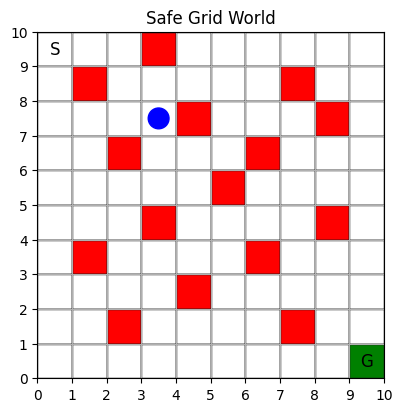

In [ ]:
# ==============================
# Environment validation and visualisation
# ==============================

# I create a fixed-start environment and inspect its main grid configuration.
env_fixed = SafeGridWorld(random_start=False, seed=123)
_ = env_fixed.reset()
total_cells = env_fixed.GRID_ROWS * env_fixed.GRID_COLS
num_hazards = len(env_fixed.HAZARDS)
num_safe_cells = len(env_fixed.safe_cells)
print("Grid stats:")
print("  total cells:", total_cells)
print("  hazards:", num_hazards)
print("  safe cells (excluding goal):", num_safe_cells)
print("  goal:", env_fixed.GOAL_POS)
print("  start:", env_fixed.START_POS)
print()

# I sample repeated random starts and verify that each sampled state is safe.
env_rand = SafeGridWorld(random_start=True, seed=123)
rand_starts = []
for _ in range(10):
    rand_starts.append(env_rand.reset())
unique_starts = sorted(set(rand_starts))
all_safe = all(s not in env_rand.HAZARDS and s != env_rand.GOAL_POS for s in unique_starts)
print("Random-start samples (10 resets):", rand_starts)
print("Unique random-starts:", unique_starts)
print("All samples are safe and not goal:", all_safe)
print()

# I test boundary handling by applying actions that would otherwise leave the grid.
env_fixed.state = (0, 0)
res_up = env_fixed.step(UP)     # I expect the agent to stay in place.
env_fixed.state = (0, 0)
res_left = env_fixed.step(LEFT) # I expect the agent to stay in place.
print("Boundary test from (0,0):")
print("  step UP    ->", res_up)
print("  step LEFT  ->", res_left)
print()

# I find a safe state next to a hazard and step into the hazard to test terminal behaviour.
env_h = SafeGridWorld(random_start=False, seed=7)
_ = env_h.reset()
found = None
for s in env_h.all_nonterminal_states():
    for a in ACTIONS:
        ns = env_h.compute_next_position(s, a)
        if ns in env_h.HAZARDS:
            found = (s, a, ns)
            break
    if found:
        break

if found is not None:
    s, a, ns = found
    env_h.state = s
    res_h = env_h.step(a)
    print("Hazard termination test:")
    print("  from state:", s, "action:", ACTION_NAMES[a], "-> next:", ns)
    print("  result:", res_h)
else:
    print("Hazard termination test: no adjacent hazard state found (unexpected).")
print()

# I place the agent next to the goal and step into it to test goal termination.
env_g = SafeGridWorld(random_start=False, seed=1)
env_g.state = (9, 8)
res_g = env_g.step(RIGHT)
print("Goal termination test:")
print("  from state: (9, 8) action: RIGHT ->", res_g)
print()

# I run a short action sequence and render the resulting state with Matplotlib.
env_vis = SafeGridWorld(random_start=False, seed=5)
_ = env_vis.reset()
demo_actions = [RIGHT, RIGHT, DOWN, RIGHT, DOWN]
for a in demo_actions:
    _ = env_vis.step(a)

print("Matplotlib render preview:")
env_vis.render(mode="matplotlib")

### Part 2 Summary: Safe GridWorld Environment

In this part, I implemented and validated the GridWorld environment used by the later safe reinforcement learning experiments.

I built the environment around a `SafeGridWorld` class with:

* four discrete actions
* fixed-start and random safe-start modes
* explicit start, goal, safe, and hazard-state definitions
* reward logic for normal movement, hazards, and goal completion
* one shared `StepResult` format for transition outputs
* ASCII and Matplotlib rendering options

I also ran environment checks before training any agent. These checks verify the grid configuration, random-start safety, boundary handling, hazard termination, goal termination, and visual rendering.

The validation output reports the current grid statistics and transition results directly from the environment, so the exact values stay tied to the latest run rather than being hard-coded in the written analysis.

## Part 3: Core Tabular Q-Learning Trainer

In this part, I implement the tabular Q-learning trainer used as the baseline training loop for the GridWorld experiments.

The trainer handles the main reinforcement learning process:

* initialising a Q-table over grid states and actions
* selecting actions with an ε-greedy strategy
* updating Q-values after each transition
* decaying exploration over training
* recording reward, episode length, and hazard violations

I keep the training logs in a consistent format so later sections can compare both learning behaviour and safety behaviour without rewriting the training loop.

At the end, I run a short sanity check to confirm that the trainer executes correctly and returns the expected fields. I treat this output as a diagnostic run only, not as the final evaluation of the agent.

In [ ]:
# ==============================
# Part 3 — Core tabular Q-learning trainer
# ==============================

def q_learning_train(env: SafeGridWorld,
                     alpha: float = 0.1,
                     gamma: float = 0.99,
                     epsilon_start: float = 1.0,
                     epsilon_min: float = 0.01,
                     epsilon_decay: float = 0.995,
                     episodes: int = 2000,
                     max_steps: int = 200,
                     verbose: bool = False) -> Dict[str, Any]:
    # I initialise one action-value vector for each grid position.
    Q = {}
    for r in range(env.GRID_ROWS):
        for c in range(env.GRID_COLS):
            Q[(r, c)] = np.zeros(env.action_space_n())

    # I keep episode-level logs for later performance and safety analysis.
    rewards, lengths, violations = [], [], []
    eps = epsilon_start
    timer = SimpleTimer()
    timer.start()

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0.0
        steps = 0
        violated = 0

        for t in range(max_steps):
            # I select an action with epsilon-greedy exploration.
            if random.random() < eps:
                action = random.choice(ACTIONS)
            else:
                action = int(np.argmax(Q[state]))

            # I apply the action and observe the next transition.
            result = env.step(action)
            next_state, reward, done, info = result
            total_reward += reward

            # I record whether the episode reaches an unsafe state.
            if info.get("event") == "hazard":
                violated = 1

            # I update the selected Q-value using the Q-learning target.
            best_next = np.max(Q[next_state])
            Q[state][action] += alpha * (reward + gamma * best_next - Q[state][action])

            state = next_state
            steps += 1

            if done:
                break

        # I reduce exploration gradually while keeping a minimum exploration level.
        eps = max(epsilon_min, eps * epsilon_decay)

        rewards.append(total_reward)
        lengths.append(steps)
        violations.append(violated)

        if verbose and (ep + 1) % 100 == 0:
            print(f"Episode {ep+1}/{episodes}  Reward={total_reward:.2f}  Eps={eps:.3f}  Violation={violated}")

    total_time = timer.stop()
    eps_per_sec = episodes / total_time if total_time > 0 else 0.0

    # I return the learned Q-table and the logs needed by later comparison steps.
    return {
        "Q": Q,
        "rewards": rewards,
        "lengths": lengths,
        "violations": violations,
        "train_time": total_time,
        "eps_per_sec": eps_per_sec,
    }


# ------------------------------
# Quick short-run test
# ------------------------------
print("Short test run (100 episodes, penalty=-0.1):")
env_test = SafeGridWorld(step_penalty=-0.1, random_start=False)
res_test = q_learning_train(env_test, episodes=100, verbose=True)
print("\nTest summary:")
print("  Episodes:", len(res_test["rewards"]))
print("  Total time (s):", f"{res_test['train_time']:.2f}")
print("  Training speed (eps/sec):", f"{res_test['eps_per_sec']:.2f}")
print("  Total violations:", sum(res_test["violations"]))
print("  Mean reward:", np.mean(res_test["rewards"]))
print("  Mean episode length:", np.mean(res_test["lengths"]))

Short test run (100 episodes, penalty=-0.1):
Episode 100/100  Reward=-10.80  Eps=0.606  Violation=1

Test summary:
  Episodes: 100
  Total time (s): 0.01
  Training speed (eps/sec): 12643.73
  Total violations: 100
  Mean reward: -10.826999999999998
  Mean episode length: 9.27


### Part 3 Summary: Core Tabular Q-Learning Trainer

In this part, I implemented the baseline Q-learning training loop for the Safe GridWorld environment.

The trainer builds a Q-table over the grid state-action space and updates it through repeated environment interaction. I use an ε-greedy policy so the agent can balance exploration and exploitation during training.

I also record several episode-level metrics for later comparison:

* total reward
* episode length
* hazard violation flag
* training time
* training speed

The short test run confirms that the trainer returns the learned Q-table and all expected logs. I use this run as a functionality check only; the final performance and safety conclusions are based on the later evaluation sections.

## Part 4: Baseline Q-Learning Experiments

In this part, I compare baseline tabular Q-learning under two step-penalty settings while keeping the start condition fixed.

The goal of this experiment is to see how reward design affects:

- learning progress
- path efficiency
- safety violations
- success behaviour
- training speed

I first define a helper that turns raw training logs into a shared set of comparison metrics. These metrics include recent success rate, recent average reward, recent average episode length, total safety violations, training speed, and a rolling success-rate series for plotting.

I then run the same training pipeline under both step-penalty settings. This keeps the comparison consistent because the environment structure, training loop, and evaluation logic all stay the same.

After training, I organise the results into a comparison table and visualise four training curves:

- smoothed reward
- smoothed episode length
- cumulative safety violations
- rolling success rate

At the end of the experiment, I select the stronger baseline using the recent success metric from the computed logs. I treat the printed table, plots, and selected configuration as run-specific results rather than fixed conclusions.

Running baseline with step penalty = -1.0
Running baseline with step penalty = -0.1

=== Baseline comparison (fixed start) ===
      config  success_rate_last25(%)  avg_reward_last25  avg_length_last25  total_violations  train_speed(eps/sec)
penalty=-1.0                     0.0             -7.604              17.88               590               6112.43
penalty=-0.1                    97.4              7.785              17.95               508               6501.21

Saved plot: /content/safe_rl_gridworld/plots/baseline_q_learning_comparison.png


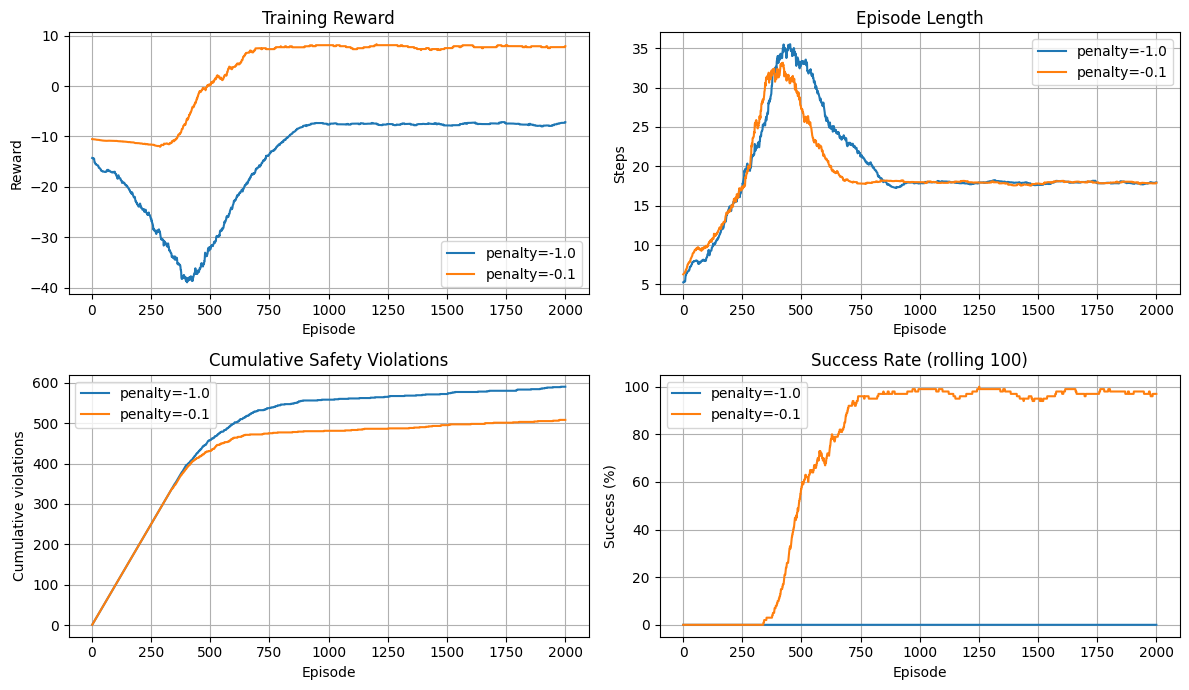


Selected better configuration for later tasks: penalty=-0.1


In [ ]:
# ==============================
# Part 4 — Baseline Q-learning experiments
# ==============================

def compute_metrics_from_logs(rewards, lengths, violations, train_time_sec, episodes, window_success=100):
    # I summarise recent training behaviour using the final portion of the recorded logs.
    M = max(1, int(0.25 * episodes))
    last_rewards = rewards[-M:]
    last_lengths = lengths[-M:]
    last_success = [1 if r > 0.0 else 0 for r in last_rewards]

    # I compute shared metrics for learning quality, safety, and training efficiency.
    metrics = {
        "success_rate_last25": 100.0 * (sum(last_success) / float(M)),
        "avg_reward_last25": float(np.mean(last_rewards)),
        "avg_length_last25": float(np.mean(last_lengths)),
        "total_violations": int(sum(violations)),
        "train_speed_eps_per_sec": episodes / train_time_sec if train_time_sec > 0 else 0.0,
    }

    # I build a rolling success-rate series so I can visualise training stability over time.
    roll = []
    wins = deque(maxlen=window_success)
    for r in rewards:
        wins.append(1 if r > 0.0 else 0)
        roll.append(100.0 * (sum(wins) / len(wins)))
    metrics["rolling_success_series"] = roll
    return metrics


def run_baseline_experiment(step_penalty: float,
                            episodes: int = 2000,
                            alpha: float = 0.1,
                            gamma: float = 0.99,
                            eps_start: float = 1.0,
                            eps_min: float = 0.01,
                            eps_decay: float = 0.995,
                            max_steps: int = 200,
                            seed: int = 42):
    # I use a fixed-start environment so both penalty settings are compared under the same conditions.
    env = SafeGridWorld(step_penalty=step_penalty, random_start=False, seed=seed)
    result = q_learning_train(
        env=env,
        alpha=alpha,
        gamma=gamma,
        epsilon_start=eps_start,
        epsilon_min=eps_min,
        epsilon_decay=eps_decay,
        episodes=episodes,
        max_steps=max_steps,
        verbose=False,
    )

    # I convert raw episode logs into the shared metrics used for comparison.
    metrics = compute_metrics_from_logs(
        rewards=result["rewards"],
        lengths=result["lengths"],
        violations=result["violations"],
        train_time_sec=result["train_time"],
        episodes=episodes,
    )
    return env, result, metrics


# ------------------------------
# Run baseline configurations
# ------------------------------
episodes = 2000
print("Running baseline with step penalty = -1.0")
env_harsh, res_harsh, met_harsh = run_baseline_experiment(step_penalty=-1.0, episodes=episodes, seed=123)

print("Running baseline with step penalty = -0.1")
env_gentle, res_gentle, met_gentle = run_baseline_experiment(step_penalty=-0.1, episodes=episodes, seed=123)

# ------------------------------
# Build comparison table
# ------------------------------

# I organise the computed metrics into a table for side-by-side comparison.
comp_df = pd.DataFrame([
    {
        "config": "penalty=-1.0",
        "success_rate_last25(%)": round(met_harsh["success_rate_last25"], 2),
        "avg_reward_last25": round(met_harsh["avg_reward_last25"], 3),
        "avg_length_last25": round(met_harsh["avg_length_last25"], 2),
        "total_violations": met_harsh["total_violations"],
        "train_speed(eps/sec)": round(met_harsh["train_speed_eps_per_sec"], 2),
    },
    {
        "config": "penalty=-0.1",
        "success_rate_last25(%)": round(met_gentle["success_rate_last25"], 2),
        "avg_reward_last25": round(met_gentle["avg_reward_last25"], 3),
        "avg_length_last25": round(met_gentle["avg_length_last25"], 2),
        "total_violations": met_gentle["total_violations"],
        "train_speed(eps/sec)": round(met_gentle["train_speed_eps_per_sec"], 2),
    },
])

print("\n=== Baseline comparison (fixed start) ===")
print(comp_df.to_string(index=False))

# ------------------------------
# Visualise learning and safety behaviour
# ------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# I compare smoothed reward curves across the two penalty settings.
plot_series(res_harsh["rewards"], "Training Reward", "Reward", label="penalty=-1.0", ax=axes[0, 0], smooth_window=100)
plot_series(res_gentle["rewards"], "Training Reward", "Reward", label="penalty=-0.1", ax=axes[0, 0], smooth_window=100)

# I compare smoothed episode lengths to inspect path efficiency during training.
plot_series(res_harsh["lengths"], "Episode Length", "Steps", label="penalty=-1.0", ax=axes[0, 1], smooth_window=100)
plot_series(res_gentle["lengths"], "Episode Length", "Steps", label="penalty=-0.1", ax=axes[0, 1], smooth_window=100)

# I plot cumulative safety violations to track unsafe exploration over time.
cum_harsh = np.cumsum(res_harsh["violations"])
cum_gentle = np.cumsum(res_gentle["violations"])
axes[1, 0].plot(np.arange(1, len(cum_harsh) + 1), cum_harsh, label="penalty=-1.0")
axes[1, 0].plot(np.arange(1, len(cum_gentle) + 1), cum_gentle, label="penalty=-0.1")
axes[1, 0].set_title("Cumulative Safety Violations")
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylabel("Cumulative violations")
axes[1, 0].legend()

# I plot rolling success rate to show how reliably the agent reaches the goal over time.
axes[1, 1].plot(np.arange(1, len(met_harsh["rolling_success_series"]) + 1), met_harsh["rolling_success_series"], label="penalty=-1.0")
axes[1, 1].plot(np.arange(1, len(met_gentle["rolling_success_series"]) + 1), met_gentle["rolling_success_series"], label="penalty=-0.1")
axes[1, 1].set_title("Success Rate (rolling 100)")
axes[1, 1].set_xlabel("Episode")
axes[1, 1].set_ylabel("Success (%)")
axes[1, 1].legend()

plt.tight_layout()
out_path = save_plot(fig, "baseline_q_learning_comparison.png")
print("\nSaved plot:", out_path)
plt.show()

# ------------------------------
# Select configuration for later experiments
# ------------------------------

# I select the stronger configuration using recent success rate from the recorded logs.
better_cfg = "penalty=-0.1" if met_gentle["success_rate_last25"] >= met_harsh["success_rate_last25"] else "penalty=-1.0"
print("\nSelected better configuration for later tasks:", better_cfg)

### Persisting Baseline Artefacts

I save the selected baseline result so later sections can reuse it without repeating the same training run.

The selected run comes from the previous comparison step, where I carry forward the configuration with stronger recent success behaviour in the current run.

I save three artefact types:

* **Q-table**: learned state-action values and the training setup used to produce them
* **Episode logs**: reward, episode length, safety violation flag, and success indicator for each episode
* **Metric summary**: the compact comparison metrics for the selected baseline

At the end, I print the selected configuration, saved file paths, and small table previews. I use these outputs as a save-check rather than fixed analysis results.

In [ ]:
# ==============================
# Persist selected baseline artefacts
# ==============================

# I choose the baseline run selected by the previous comparison step.
if better_cfg == "penalty=-0.1":
    best_penalty = -0.1
    best_Q = res_gentle["Q"]
    best_res = res_gentle
    best_met = met_gentle
else:
    best_penalty = -1.0
    best_Q = res_harsh["Q"]
    best_res = res_harsh
    best_met = met_harsh

# I build output paths using a short tag for the selected penalty setting.
tag = "m0p1" if best_penalty == -0.1 else "m1p0"
qtable_path = DIRS["qtables"] / f"baseline_qtable_{tag}.pkl"
logs_csv_path = DIRS["reports"] / f"baseline_episode_logs_{tag}.csv"
metrics_csv_path = DIRS["reports"] / f"baseline_metrics_summary_{tag}.csv"

# I save the selected Q-table with the training setup needed to interpret it later.
with open(qtable_path, "wb") as f:
    pickle.dump({
        "Q": best_Q,
        "config": {
            "step_penalty": best_penalty,
            "alpha": 0.1,
            "gamma": 0.99,
            "epsilon_start": 1.0,
            "epsilon_min": 0.01,
            "epsilon_decay": 0.995,
            "episodes": len(best_res["rewards"]),
            "max_steps": 200,
            "start_mode": "fixed",
            "seed": 123,
        }
    }, f)

# I assemble per-episode logs so I can inspect the selected run later.
ep_df = pd.DataFrame({
    "episode": np.arange(1, len(best_res["rewards"]) + 1),
    "reward": best_res["rewards"],
    "length": best_res["lengths"],
    "violation": best_res["violations"],
})
ep_df["success"] = (ep_df["reward"] > 0).astype(int)
ep_df.to_csv(logs_csv_path, index=False)

# I save the selected run's summary metrics as a compact table.
met_df = pd.DataFrame([{
    "config": f"penalty={best_penalty}",
    "success_rate_last25(%)": best_met["success_rate_last25"],
    "avg_reward_last25": best_met["avg_reward_last25"],
    "avg_length_last25": best_met["avg_length_last25"],
    "total_violations": best_met["total_violations"],
    "train_speed(eps/sec)": best_met["train_speed_eps_per_sec"],
}])
met_df.to_csv(metrics_csv_path, index=False)

# I print file locations and table previews to confirm that the artefacts were created.
print("Best configuration selected:", f"penalty={best_penalty}")
print("Saved Q-table to:", qtable_path)
print("Saved episode logs to:", logs_csv_path)
print("Saved metrics summary to:", metrics_csv_path)

# I preview the first rows of the episode-level log table.
print("\nEpisode logs preview:")
print(ep_df.head().to_string(index=False))

# I preview the selected run's summary metrics.
print("\nMetrics summary:")
print(met_df.to_string(index=False))

Best configuration selected: penalty=-0.1
Saved Q-table to: /content/safe_rl_gridworld/qtables/baseline_qtable_m0p1.pkl
Saved episode logs to: /content/safe_rl_gridworld/reports/baseline_episode_logs_m0p1.csv
Saved metrics summary to: /content/safe_rl_gridworld/reports/baseline_metrics_summary_m0p1.csv

Episode logs preview:
 episode  reward  length  violation  success
       1   -10.2       3          1        0
       2   -10.6       7          1        0
       3   -10.5       6          1        0
       4   -10.7       8          1        0
       5   -10.4       5          1        0

Metrics summary:
      config  success_rate_last25(%)  avg_reward_last25  avg_length_last25  total_violations  train_speed(eps/sec)
penalty=-0.1                    97.4             7.7852             17.948               508           6501.214433


### Part 4 Summary: Baseline Q-Learning Experiments

In this part, I tested the baseline Q-learning agent under two step-penalty settings and compared their learning and safety behaviour under the same fixed-start setup.

I evaluated each run using the same set of metrics:

* recent success rate
* recent average reward
* recent average episode length
* total safety violations
* training speed

I also visualised four training curves to compare reward growth, episode length, cumulative violations, and rolling success rate over time.

Based on the computed comparison table, I selected the stronger baseline configuration for later experiments and saved its Q-table, episode logs, and metric summary. The exact metric values are kept in the generated tables and saved artefacts, so the written summary stays consistent when the notebook is rerun.

## Part 5: Danger Map Construction

In this part, I build a danger map that measures how close each GridWorld cell is to the nearest hazard.

I use this map as a reusable safety signal for later experiments, especially when I need the agent to reason about unsafe regions beyond immediate collisions.

To construct the map, I use multi-source breadth-first search. I start the search from all hazard cells at once, which lets me compute the minimum hazard distance for the full grid in a single pass.

I also add small helper functions to:

- save the danger map for later reuse
- convert the map into a matrix form for plotting

This matrix keeps the same row-column layout as the environment, so it is easy to inspect visually.

At the end of the cell, I save the computed map, print a few runtime checks, preview part of the matrix, and render a heatmap. I use these outputs as validation of the generated safety structure rather than as fixed analysis results.

Danger map computed.
Saved to: /content/safe_rl_gridworld/data/danger_map.pkl
Grid shape: (10, 10)
Min distance (should be 0): 0
Max distance: 3
Sample values at key cells:
  START (0,0): 2
  GOAL  (9,9): 3
  A hazard (7, 4) : 0

Top-left 5x5 preview (row 0..4, col 0..4):
[[2 1 1 0 1]
 [1 0 1 1 1]
 [2 1 1 1 0]
 [2 1 0 1 1]
 [3 2 1 1 1]]

Saved heatmap: /content/safe_rl_gridworld/plots/danger_map_heatmap.png


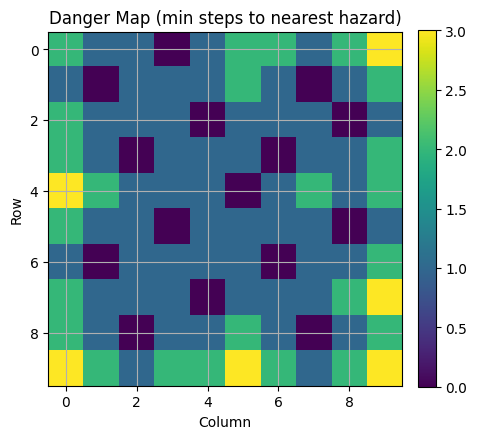

In [ ]:
# ==============================
# Part 5 — Danger map construction
# ==============================

from collections import deque

def compute_danger_map(env: SafeGridWorld) -> Dict[Tuple[int, int], int]:
    # I compute the nearest-hazard distance for each grid cell with multi-source BFS.
    D: Dict[Tuple[int, int], int] = {}
    q: deque = deque()

    # I initialise the search frontier with all hazard cells.
    for h in env.HAZARDS:
        D[h] = 0
        q.append(h)

    # I expand the search until every grid cell receives its nearest-hazard distance.
    while q:
        r, c = q.popleft()
        d = D[(r, c)]
        for a in ACTIONS:
            nr, nc = env.compute_next_position((r, c), a)

            # I assign a distance only the first time a cell is reached.
            if (nr, nc) not in D:
                D[(nr, nc)] = d + 1
                q.append((nr, nc))

    # I verify that the danger map covers the full grid.
    assert len(D) == env.GRID_ROWS * env.GRID_COLS, "Danger map incomplete"
    return D


def save_danger_map(danger_map: Dict[Tuple[int, int], int], path: Path) -> None:
    # I save the danger map so later sections can reuse it without recomputing it.
    with open(path, "wb") as f:
        pickle.dump({"danger_map": danger_map}, f)


def danger_map_to_array(env: SafeGridWorld, danger_map: Dict[Tuple[int, int], int]) -> np.ndarray:
    # I convert the dictionary-based map into a row-column matrix for plotting.
    arr = np.zeros((env.GRID_ROWS, env.GRID_COLS), dtype=int)
    for r in range(env.GRID_ROWS):
        for c in range(env.GRID_COLS):
            arr[r, c] = danger_map[(r, c)]
    return arr


# ------------------------------
# Build and save danger map
# ------------------------------

# I create an environment instance and compute the nearest-hazard distance map.
env_for_map = SafeGridWorld(random_start=False, step_penalty=-0.1, seed=42)
D_map = compute_danger_map(env_for_map)
arr = danger_map_to_array(env_for_map, D_map)

# I save the computed danger map for later safety-aware experiments.
danger_map_path = DIRS["data"] / "danger_map.pkl"
save_danger_map(D_map, danger_map_path)

# ------------------------------
# Runtime verification
# ------------------------------

# I print key checks to confirm that the map was created and saved correctly.
print("Danger map computed.")
print("Saved to:", danger_map_path)
print("Grid shape:", arr.shape)
print("Min distance (should be 0):", int(arr.min()))
print("Max distance:", int(arr.max()))
print("Sample values at key cells:")
print("  START (0,0):", D_map[(0, 0)])
print("  GOAL  (9,9):", D_map[(9, 9)])
any_h = next(iter(env_for_map.HAZARDS))
print("  A hazard", any_h, ":", D_map[any_h])

# I preview a small corner of the danger-map matrix for quick inspection.
print("\nTop-left 5x5 preview (row 0..4, col 0..4):")
print(arr[0:5, 0:5])

# ------------------------------
# Heatmap visualisation
# ------------------------------

# I visualise the danger map so the safety structure is easier to inspect.
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(arr, origin="upper")
ax.set_title("Danger Map (min steps to nearest hazard)")
ax.set_xlabel("Column")
ax.set_ylabel("Row")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
out_plot = save_plot(fig, "danger_map_heatmap.png")
print("\nSaved heatmap:", out_plot)
plt.show()

### Labeled Dataset Construction and Stratified Splits

I convert the danger map into a supervised dataset for training the safety classifier.

Each sample represents one **state-action pair** from the non-terminal GridWorld states. For each pair, I compute:

* current state
* selected action
* next state
* current danger distance
* next danger distance
* safety label based on the next state

The feature vector combines position, action, transition, and danger-map information. The label turns the next-state danger distance into a small set of safety classes, so the later classifier can learn whether an action moves the agent toward a risky area.

I then create stratified train, validation, and test splits. This keeps the label balance similar across the three subsets, which is useful because some safety classes appear less often than others.

At the end, I save the prepared arrays and print dataset checks, including sample count, feature dimension, class distribution, split sizes, and one example transition. These values are generated from the current environment setup, so I treat them as verification output rather than fixed written conclusions.

In [ ]:
# ==============================
# Labeled dataset construction and stratified splits
# ==============================

from sklearn.model_selection import train_test_split

def build_dataset(env: SafeGridWorld, danger_map: Dict[Tuple[int, int], int]) -> Dict[str, Any]:
    # I keep feature names so the generated columns remain easy to interpret.
    feature_names = [
        "cur_x_norm", "cur_y_norm",
        "a_up", "a_down", "a_left", "a_right",
        "next_x_norm", "next_y_norm",
        "d_cur_norm", "d_next_norm",
    ]

    X, y = [], []
    rows_meta = []  # I keep metadata so I can trace each sample back to its transition.

    n = env.GRID_ROWS

    for r in range(env.GRID_ROWS):
        for c in range(env.GRID_COLS):
            s = (r, c)
            if s in env.HAZARDS or s == env.GOAL_POS:
                continue

            for a in ACTIONS:
                s_next = env.compute_next_position(s, a)
                d_cur = danger_map[s]
                d_next = danger_map[s_next]

                # I map the next-state danger distance into a discrete safety class.
                if d_next == 0:
                    cls = 0
                elif d_next == 1:
                    cls = 1
                elif d_next == 2:
                    cls = 2
                else:
                    cls = 3

                # I encode the selected action as a one-hot vector.
                a_onehot = [
                    1.0 if a == UP else 0.0,
                    1.0 if a == DOWN else 0.0,
                    1.0 if a == LEFT else 0.0,
                    1.0 if a == RIGHT else 0.0,
                ]

                # I combine state, action, next-state, and danger-map information.
                feat = [
                    r / n, c / n,
                    *a_onehot,
                    s_next[0] / n, s_next[1] / n,
                    d_cur / 10.0, d_next / 10.0,
                ]

                X.append(feat)
                y.append(cls)
                rows_meta.append((s, a, s_next, d_cur, d_next))

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int64)
    assert X.shape[0] == 84 * 4, "Expected 336 samples"

    return {
        "X": X,
        "y": y,
        "feature_names": feature_names,
        "meta": rows_meta,
    }


def stratified_splits(X: np.ndarray, y: np.ndarray, seed: int = 42):
    # I create train, validation, and test splits while preserving label balance.
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=seed, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=seed, stratify=y_temp
    )
    return X_train, y_train, X_val, y_val, X_test, y_test


# I build the dataset from the danger map computed earlier.
dataset = build_dataset(env_for_map, D_map)
X, y = dataset["X"], dataset["y"]
X_train, y_train, X_val, y_val, X_test, y_test = stratified_splits(X, y, seed=42)

# I count labels in each split to check the stratified split behaviour.
def class_counts(vec: np.ndarray) -> Dict[int, int]:
    unique, counts = np.unique(vec, return_counts=True)
    return {int(k): int(v) for k, v in zip(unique, counts)}

dist_all = class_counts(y)
dist_tr  = class_counts(y_train)
dist_va  = class_counts(y_val)
dist_te  = class_counts(y_test)

# I save the feature names and split arrays so later sections can reload the dataset.
complete_ds_path = DIRS["data"] / "complete_dataset.pkl"
with open(complete_ds_path, "wb") as f:
    pickle.dump({
        "feature_names": dataset["feature_names"],
        "X_train": X_train, "y_train": y_train,
        "X_val": X_val, "y_val": y_val,
        "X_test": X_test, "y_test": y_test,
    }, f)

# I print runtime checks for the saved dataset and split structure.
print("Dataset built and saved to:", complete_ds_path)
print("Total samples:", X.shape[0], "(expected 336)")
print("Feature dim:", X.shape[1], "(expected 10)")
print("Class distribution (all):", dist_all)
print("Train/Val/Test sizes:", len(y_train), len(y_val), len(y_test))
print("Class distribution (train):", dist_tr)
print("Class distribution (val):  ", dist_va)
print("Class distribution (test): ", dist_te)

# I inspect one generated row together with its source transition metadata.
idx = 0
print("\nSample feature row 0:", X[idx].tolist(), "label:", int(y[idx]))
print("Meta (s, a, s_next, d_cur, d_next):", dataset["meta"][idx])

Dataset built and saved to: /content/safe_rl_gridworld/data/complete_dataset.pkl
Total samples: 336 (expected 336)
Feature dim: 10 (expected 10)
Class distribution (all): {0: 59, 1: 161, 2: 94, 3: 22}
Train/Val/Test sizes: 235 50 51
Class distribution (train): {0: 41, 1: 113, 2: 66, 3: 15}
Class distribution (val):   {0: 9, 1: 24, 2: 14, 3: 3}
Class distribution (test):  {0: 9, 1: 24, 2: 14, 3: 4}

Sample feature row 0: [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.20000000298023224, 0.20000000298023224] label: 2
Meta (s, a, s_next, d_cur, d_next): ((0, 0), 0, (0, 0), 2, 2)


### Part 5 Summary: Danger Map and Safety Dataset

In this part, I built the safety signal used by the later neural safety shield.

I first constructed a danger map with multi-source BFS, starting from all hazard cells and assigning each grid cell a nearest-hazard distance. I then visualised the result as a heatmap so the safety structure of the environment could be inspected directly.

I also converted the danger map into a supervised learning dataset for the safety classifier. Each sample represents one state-action transition and includes:

* current position
* action encoding
* next position
* current and next danger-distance features
* a discrete safety label based on the next state's hazard distance

The dataset is split into train, validation, and test subsets using stratification, so the four safety classes remain reasonably balanced across evaluation stages.

The saved artefacts include the danger map, heatmap, feature arrays, labels, and split data. The exact sample counts, class distributions, and split sizes are printed from the current run, so the notebook keeps the quantitative checks tied to the generated dataset rather than hard-coding them in the written summary.

## Part 6: Safety Shield Classifier Training

In this part, I train a neural safety shield to classify the danger level of each state-action pair.

I start by loading the supervised dataset built from the danger map. The saved train and validation splits are converted into PyTorch tensors, and I print their shapes as a quick loading check.

The classifier is a compact feed-forward neural network:

* input: engineered state-action features
* hidden layers: nonlinear feature learning
* output: logits for the safety classes

I train the model with cross-entropy loss. During each epoch, I shuffle the training data, update the model in mini-batches, and evaluate validation loss after the epoch finishes.

The printed loss values are used as training diagnostics. I use the loss curve to check whether the shield is learning the safety labels, but I avoid treating one run’s exact loss values as fixed results.

In [ ]:
# ==============================
# Part 6 — Safety shield classifier training
# ==============================

# I load the supervised safety dataset prepared in the previous part.
data_path = DIRS["data"] / "complete_dataset.pkl"
with open(data_path, "rb") as f:
    ds = pickle.load(f)

# I convert the saved train and validation splits into PyTorch tensors.
X_train = torch.tensor(ds["X_train"], dtype=torch.float32)
y_train = torch.tensor(ds["y_train"], dtype=torch.long)
X_val   = torch.tensor(ds["X_val"], dtype=torch.float32)
y_val   = torch.tensor(ds["y_val"], dtype=torch.long)

print("Loaded dataset shapes:")
print("  Train:", X_train.shape, "Val:", X_val.shape)

# ------------------------------
# Neural network model
# ------------------------------
class SafetyShieldNet(nn.Module):
    def __init__(self, input_dim=10, hidden_dim1=64, hidden_dim2=64, output_dim=4):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc3 = nn.Linear(hidden_dim2, output_dim)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        # I return logits because CrossEntropyLoss handles class normalisation internally.
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x  # logits only


# ------------------------------
# Training function
# ------------------------------
def train_shield(model, X_train, y_train, X_val, y_val,
                 lr=0.001, batch_size=32, epochs=100, seed=42):
    # I set the training seed and use GPU acceleration when it is available.
    torch.manual_seed(seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    n_train = X_train.shape[0]

    for epoch in range(epochs):
        # I shuffle the training data at the start of each epoch.
        perm = torch.randperm(n_train)
        X_train, y_train = X_train[perm], y_train[perm]

        model.train()
        epoch_loss = 0.0

        for i in range(0, n_train, batch_size):
            # I train the model one mini-batch at a time.
            xb = X_train[i:i+batch_size].to(device)
            yb = y_train[i:i+batch_size].to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * xb.size(0)

        # I check validation loss after each epoch.
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val.to(device))
            val_loss = criterion(val_logits, y_val.to(device)).item()

        # I keep the loss history for later diagnostics.
        train_loss = epoch_loss / n_train
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs}  TrainLoss={train_loss:.4f}  ValLoss={val_loss:.4f}")

    return model, train_losses, val_losses


# ------------------------------
# Train safety shield model
# ------------------------------

# I instantiate and train the safety shield with the configured settings.
model = SafetyShieldNet(hidden_dim1=64, hidden_dim2=64)
model, train_losses, val_losses = train_shield(
    model,
    X_train, y_train, X_val, y_val,
    lr=0.001, batch_size=32, epochs=100, seed=42
)

Loaded dataset shapes:
  Train: torch.Size([235, 10]) Val: torch.Size([50, 10])


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:134: UserWarning: Requested unified CUBLASLT workspace size of 1048576 bytes exceeds CUBLAS workspace size of 131072 bytes. Please increase CUBLAS workspace size via CUBLAS_WORKSPACE_CONFIG or decrease requested CUBLASLT_WORKSPACE_SIZE. Otherwise CUBLASLT workspace size will be limited to the CUBLAS workspace size. (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:228.)
  return F.linear(input, self.weight, self.bias)


Epoch   1/100  TrainLoss=1.4237  ValLoss=1.3861
Epoch  10/100  TrainLoss=1.1711  ValLoss=1.1762
Epoch  20/100  TrainLoss=1.0551  ValLoss=1.0635
Epoch  30/100  TrainLoss=0.7960  ValLoss=0.8108
Epoch  40/100  TrainLoss=0.5373  ValLoss=0.5436
Epoch  50/100  TrainLoss=0.3027  ValLoss=0.3048
Epoch  60/100  TrainLoss=0.1579  ValLoss=0.1572
Epoch  70/100  TrainLoss=0.0819  ValLoss=0.0837
Epoch  80/100  TrainLoss=0.0460  ValLoss=0.0493
Epoch  90/100  TrainLoss=0.0289  ValLoss=0.0307
Epoch 100/100  TrainLoss=0.0198  ValLoss=0.0212


### Safety Shield Evaluation and Diagnostic Plots

I evaluate the trained safety shield on the validation and test splits to check how reliably it classifies the safety level of state-action pairs.

For each split, I compute:

- overall accuracy
- per-class accuracy
- confusion matrix

This gives me both a high-level performance view and a more detailed class-by-class diagnostic.

I also generate visual diagnostics for the classifier:

- confusion matrix plots for the validation and test splits
- a loss-curve plot showing training and validation loss across epochs

At the end of the cell, I save the generated figures and print their file paths. I treat the printed metrics and plots as run-specific outputs rather than fixed written conclusions.


Validation results
------------------
Overall accuracy: 100.00%
Per-class accuracy:
  Class 0: 100.00%
  Class 1: 100.00%
  Class 2: 100.00%
  Class 3: 100.00%
Confusion matrix (rows=true, cols=pred):
[[ 9  0  0  0]
 [ 0 24  0  0]
 [ 0  0 14  0]
 [ 0  0  0  3]]

Test results
------------
Overall accuracy: 100.00%
Per-class accuracy:
  Class 0: 100.00%
  Class 1: 100.00%
  Class 2: 100.00%
  Class 3: 100.00%
Confusion matrix (rows=true, cols=pred):
[[ 9  0  0  0]
 [ 0 24  0  0]
 [ 0  0 14  0]
 [ 0  0  0  4]]


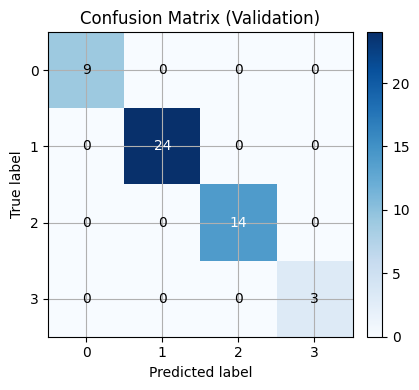

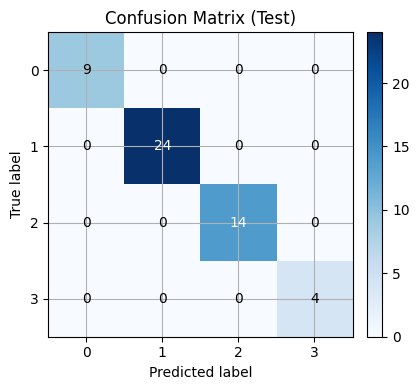

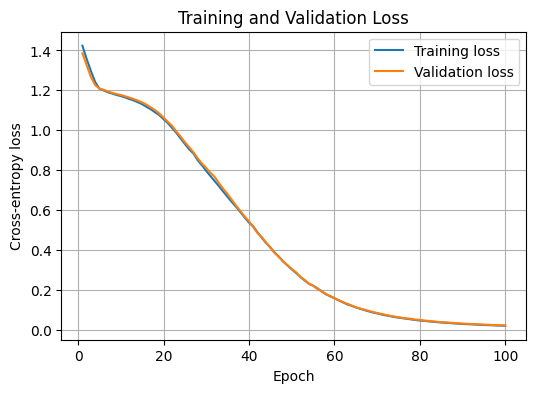


Saved figures:
  Validation CM: /content/safe_rl_gridworld/plots/safety_shield_confusion_matrix_val.png
  Test CM: /content/safe_rl_gridworld/plots/safety_shield_confusion_matrix_test.png
  Loss curves: /content/safe_rl_gridworld/plots/safety_shield_loss_curves.png


In [ ]:
# ==============================
# Safety shield evaluation and diagnostic plots
# ==============================

from sklearn.metrics import confusion_matrix
import itertools

# I convert the saved test split into tensors for final classifier evaluation.
X_test = torch.tensor(ds["X_test"], dtype=torch.float32)
y_test = torch.tensor(ds["y_test"], dtype=torch.long)

def predict_logits(model: nn.Module, X: torch.Tensor) -> np.ndarray:
    # I run the trained model in evaluation mode and return logits as a NumPy array.
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        logits = model(X.to(device))
    return logits.cpu().numpy()

def eval_split(name: str, model: nn.Module, X: torch.Tensor, y: torch.Tensor) -> Dict[str, Any]:
    # I generate predictions and compare them with the true labels for one split.
    logits = predict_logits(model, X)
    y_pred = np.argmax(logits, axis=1)
    y_true = y.numpy()

    # I compute overall classification accuracy for the split.
    acc = float((y_pred == y_true).mean())

    # I compute per-class accuracy so I can inspect class-level behaviour.
    per_class = {}
    for cls in range(4):
        idx = (y_true == cls)
        if idx.sum() > 0:
            per_class[cls] = float((y_pred[idx] == y_true[idx]).mean())
        else:
            per_class[cls] = float("nan")

    # I build the confusion matrix using the fixed safety-class order.
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])

    # I print the evaluation summary as a runtime diagnostic.
    print(f"\n{name} results")
    print("-" * (len(name) + 8))
    print(f"Overall accuracy: {acc*100:.2f}%")
    print("Per-class accuracy:")
    for cls in range(4):
        print(f"  Class {cls}: {per_class[cls]*100:.2f}%")
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm)

    return {"acc": acc, "per_class": per_class, "cm": cm, "y_pred": y_pred}

def plot_confusion_matrix(cm: np.ndarray, title: str, filename: str) -> Path:
    # I visualise the confusion matrix and annotate each cell with its count.
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set(
        xticks=np.arange(4), yticks=np.arange(4),
        xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3],
        ylabel="True label", xlabel="Predicted label",
        title=title
    )
    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )
    plt.tight_layout()
    out_path = save_plot(fig, filename)
    plt.show()
    return out_path

def plot_loss_curves(train_losses: List[float], val_losses: List[float], filename: str) -> Path:
    # I plot training and validation loss so I can inspect learning behaviour over time.
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(np.arange(1, len(train_losses) + 1), train_losses, label="Training loss")
    ax.plot(np.arange(1, len(val_losses) + 1), val_losses, label="Validation loss")
    ax.set_title("Training and Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.legend()
    out_path = save_plot(fig, filename)
    plt.show()
    return out_path

# I evaluate the trained safety shield on the validation and test splits.
val_results = eval_split("Validation", model, X_val, y_val)
test_results = eval_split("Test", model, X_test, y_test)

# I generate and save confusion matrix plots for both evaluation splits.
val_cm_path = plot_confusion_matrix(
    val_results["cm"],
    "Confusion Matrix (Validation)",
    "safety_shield_confusion_matrix_val.png"
)
test_cm_path = plot_confusion_matrix(
    test_results["cm"],
    "Confusion Matrix (Test)",
    "safety_shield_confusion_matrix_test.png"
)

# I generate and save the training-versus-validation loss curve.
loss_plot_path = plot_loss_curves(
    train_losses,
    val_losses,
    "safety_shield_loss_curves.png"
)

# I print the saved figure paths to verify that the diagnostic plots were created.
print("\nSaved figures:")
print("  Validation CM:", val_cm_path)
print("  Test CM:", test_cm_path)
print("  Loss curves:", loss_plot_path)

### Persisting the Safety Shield Model and Evaluation Artefacts

I save the trained safety shield and its evaluation outputs so later sections can reuse the model without retraining it.

I store several artefacts:

* **Model weights**: the trained `state_dict`
* **Model metadata**: architecture settings, feature names, class labels, and training setup
* **Evaluation metrics**: validation and test accuracy summaries
* **Loss history**: training and validation loss across epochs

I save the weights and metadata separately. This keeps the model reusable while still preserving the information needed to reconstruct and interpret it later.

At the end, I print the saved file paths and preview the generated tables. These outputs are used as a save-check, not as fixed written conclusions.

In [ ]:
# ==============================
# Persist safety shield artefacts
# ==============================

# I define output paths for the trained model, metadata, metrics, and loss history.
model_path = DIRS["models"] / "safety_shield_state_dict.pth"
meta_path  = DIRS["models"] / "safety_shield_meta.pkl"
val_csv    = DIRS["reports"] / "safety_shield_val_metrics.csv"
test_csv   = DIRS["reports"] / "safety_shield_test_metrics.csv"
curves_csv = DIRS["reports"] / "safety_shield_loss_curves.csv"

# I save the trained model parameters so the shield can be loaded later.
torch.save(model.state_dict(), model_path)

# I save the metadata needed to reconstruct and interpret the model.
with open(meta_path, "wb") as f:
    pickle.dump({
        "model_arch": {
            "input_dim": 10,
            "hidden_dim1": 64,
            "hidden_dim2": 64,
            "output_dim": 4,
        },
        "train_hparams": {
            "lr": 0.001,
            "batch_size": 32,
            "epochs": len(train_losses),
            "seed": 42,
            "criterion": "CrossEntropyLoss",
            "optimizer": "Adam",
        },
        "feature_names": ds.get("feature_names", [
            "cur_x_norm", "cur_y_norm", "a_up", "a_down", "a_left", "a_right",
            "next_x_norm", "next_y_norm", "d_cur_norm", "d_next_norm"
        ]),
        "class_labels": [0, 1, 2, 3],
    }, f)

# I convert one split's evaluation results into a compact metrics table.
def metrics_to_df(name: str, results: Dict[str, Any]) -> pd.DataFrame:
    acc = results["acc"]
    per = results["per_class"]
    row = {
        "split": name,
        "overall_acc": acc,
        "acc_class_0": per[0],
        "acc_class_1": per[1],
        "acc_class_2": per[2],
        "acc_class_3": per[3],
    }
    return pd.DataFrame([row])

# I save validation and test metrics as separate CSV files.
val_df = metrics_to_df("val", val_results)
test_df = metrics_to_df("test", test_results)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

# I save the loss history so the training curve can be inspected later.
curves_df = pd.DataFrame({
    "epoch": np.arange(1, len(train_losses) + 1),
    "train_loss": train_losses,
    "val_loss": val_losses,
})
curves_df.to_csv(curves_csv, index=False)

# I print saved paths to verify that all artefacts were written.
print("Saved model state_dict to:", model_path)
print("Saved model meta to:", meta_path)
print("Saved validation metrics to:", val_csv)
print("Saved test metrics to:", test_csv)
print("Saved loss curves to:", curves_csv)

# I preview the saved validation metrics table.
print("\nValidation metrics preview:")
print(val_df.to_string(index=False))

# I preview the saved test metrics table.
print("\nTest metrics preview:")
print(test_df.to_string(index=False))

# I preview the beginning of the saved loss-curve table.
print("\nLoss curves preview:")
print(curves_df.head().to_string(index=False))

Saved model state_dict to: /content/safe_rl_gridworld/models/safety_shield_state_dict.pth
Saved model meta to: /content/safe_rl_gridworld/models/safety_shield_meta.pkl
Saved validation metrics to: /content/safe_rl_gridworld/reports/safety_shield_val_metrics.csv
Saved test metrics to: /content/safe_rl_gridworld/reports/safety_shield_test_metrics.csv
Saved loss curves to: /content/safe_rl_gridworld/reports/safety_shield_loss_curves.csv

Validation metrics preview:
split  overall_acc  acc_class_0  acc_class_1  acc_class_2  acc_class_3
  val          1.0          1.0          1.0          1.0          1.0

Test metrics preview:
split  overall_acc  acc_class_0  acc_class_1  acc_class_2  acc_class_3
 test          1.0          1.0          1.0          1.0          1.0

Loss curves preview:
 epoch  train_loss  val_loss
     1    1.423721  1.386136
     2    1.356996  1.325207
     3    1.296294  1.266830
     4    1.241514  1.226106
     5    1.207885  1.208313


### Part 6 Summary: Safety Shield Classifier Training and Evaluation

In this part, I trained and evaluated the neural safety shield used later for safer action selection.

I used the labeled state-action dataset from the danger map and trained a feed-forward classifier to predict one of four safety classes. The model learns from engineered features that describe the current state, action, next state, and danger-distance values.

I evaluated the shield with:

* training and validation loss curves
* validation accuracy
* test accuracy
* per-class accuracy
* validation and test confusion matrices

In the current run, the loss curves show stable convergence, and the validation/test confusion matrices show perfect class separation across all four safety labels. I also saved the trained model weights, model metadata, evaluation metrics, and loss history so the shield can be reused in later experiments without retraining.

The exact accuracy values, class-level results, and loss values are stored in the generated reports and plots, so the written summary stays tied to the latest run rather than hard-coding one specific output.

## Part 7: Shield-Guided Safe RL Training Framework

In this part, I connect the trained safety shield with the Q-learning pipeline.

The idea is simple: the Q-learning agent can still propose actions, but the shield checks whether the proposed action looks safe before the environment executes it. This lets me reduce unsafe exploration while keeping the same reinforcement learning feedback loop.

I first reload the saved safety shield model and metadata from the previous part. This avoids retraining the classifier and keeps the safe RL stage connected to the trained shield.

I then define a `ShieldWrapper` that converts each candidate state-action pair into the same feature format used during classifier training. The wrapper returns the predicted danger class for each possible action.

Finally, I implement the shield-guided training loop:

* the agent proposes an action with ε-greedy Q-learning
* the shield predicts the danger class of available actions
* unsafe proposals are replaced with safer alternatives when possible
* the Q-table is still updated from the actual environment transition

The training logs track reward, safety violations, shield interventions, and runtime. I use these logs later to compare shield-guided learning against the baseline Q-learning run.

In [ ]:
# ==============================
# Part 7 — Shield-guided Safe RL training framework
# ==============================

# ------------------------------
# 1. Load trained safety shield model
# ------------------------------

# I load the saved metadata and model parameters from the safety-shield training stage.
meta_path = DIRS["models"] / "safety_shield_meta.pkl"
state_path = DIRS["models"] / "safety_shield_state_dict.pth"

with open(meta_path, "rb") as f:
    meta = pickle.load(f)

# I rebuild the shield model using the saved architecture settings.
arch = meta["model_arch"]
shield_model = SafetyShieldNet(
    input_dim=arch["input_dim"],
    hidden_dim1=arch["hidden_dim1"],
    hidden_dim2=arch["hidden_dim2"],
    output_dim=arch["output_dim"],
)
shield_model.load_state_dict(torch.load(state_path, map_location="cpu"))
shield_model.eval()

print("Loaded safety shield model:")
print("  Input dim:", arch["input_dim"])
print("  Hidden dims:", (arch["hidden_dim1"], arch["hidden_dim2"]))
print("  Output classes:", arch["output_dim"])


# ------------------------------
# 2. Shield wrapper
# ------------------------------
class ShieldWrapper:
    def __init__(self, model: nn.Module, env: SafeGridWorld, danger_map: Dict[Tuple[int, int], int]):
        # I keep the model, environment, and danger map together for action-safety checks.
        self.model = model
        self.env = env
        self.danger_map = danger_map
        self.device = next(model.parameters()).device

    def predict_class(self, state: Tuple[int, int], action: int) -> int:
        # I rebuild the same state-action feature format used to train the shield.
        s = state
        s_next = self.env.compute_next_position(s, action)
        d_cur = self.danger_map[s]
        d_next = self.danger_map[s_next]
        n = self.env.GRID_ROWS

        # I combine position, action, next-state, and danger-distance features.
        feat = np.array([
            s[0] / n, s[1] / n,
            1.0 if action == UP else 0.0,
            1.0 if action == DOWN else 0.0,
            1.0 if action == LEFT else 0.0,
            1.0 if action == RIGHT else 0.0,
            s_next[0] / n, s_next[1] / n,
            d_cur / 10.0, d_next / 10.0,
        ], dtype=np.float32)

        # I run the shield in inference mode and return the predicted danger class.
        with torch.no_grad():
            logits = self.model(torch.tensor(feat).unsqueeze(0).to(self.device))
            cls = int(torch.argmax(logits, dim=1).cpu().item())
        return cls


# ------------------------------
# 3. Safe RL training function
# ------------------------------
def train_safe_rl(Q_init: Dict[Tuple[int, int], np.ndarray],
                  env: SafeGridWorld,
                  shield: ShieldWrapper,
                  danger_map: Dict[Tuple[int, int], int],
                  alpha: float = 0.1,
                  gamma: float = 0.99,
                  epsilon_start: float = 1.0,
                  epsilon_min: float = 0.01,
                  epsilon_decay: float = 0.995,
                  episodes: int = 1000,
                  max_steps: int = 200,
                  theta: int = 2,
                  seed: int = 123) -> Dict[str, Any]:

    # I copy the initial Q-table so this run does not overwrite the baseline table.
    rng = random.Random(seed)
    Q = {k: v.copy() for k, v in Q_init.items()}
    eps = epsilon_start

    # I record learning progress, unsafe events, and shield interventions.
    rewards, violations, interventions = [], [], []
    timer = SimpleTimer()
    timer.start()

    for ep in range(episodes):
        s = env.reset()
        total_r, violated, intervene_ct = 0.0, 0, 0

        for t in range(max_steps):
            # I first let epsilon-greedy Q-learning propose an action.
            if rng.random() < eps:
                a_prop = rng.choice(ACTIONS)
            else:
                a_prop = int(np.argmax(Q[s]))

            # I ask the shield to score every action available from the current state.
            predicted_classes = [shield.predict_class(s, a) for a in ACTIONS]
            pred_class_prop = predicted_classes[a_prop]

            # I execute the proposed action only if it passes the safety threshold.
            if pred_class_prop > theta:
                a_exec = a_prop
            else:
                # I prefer safe candidate actions with the highest current Q-value.
                candidates = [a for a in ACTIONS if predicted_classes[a] > theta]
                if candidates:
                    a_exec = max(candidates, key=lambda a: Q[s][a])
                else:
                    # I fall back to the least risky predicted class, then break ties by Q-value.
                    max_risk_class = max(predicted_classes)
                    candidates = [a for a, c in enumerate(predicted_classes) if c == max_risk_class]
                    a_exec = max(candidates, key=lambda a: Q[s][a])
                intervene_ct += 1

            # I execute the selected action and update the Q-table from the observed transition.
            result = env.step(a_exec)
            s_next, r, done, info = result
            total_r += r

            if info.get("event") == "hazard":
                violated += 1

            best_next = np.max(Q[s_next])
            Q[s][a_exec] += alpha * (r + gamma * best_next - Q[s][a_exec])

            s = s_next
            if done:
                break

        # I decay exploration and store episode-level logs.
        eps = max(epsilon_min, eps * epsilon_decay)
        rewards.append(total_r)
        violations.append(violated)
        interventions.append(intervene_ct)

        if (ep + 1) % 100 == 0:
            print(f"Episode {ep+1:4d}/{episodes}  Reward={total_r:.2f}  Viol={violated}  Interv={intervene_ct}  eps={eps:.3f}")

    total_time = timer.stop()

    # I return the updated Q-table and logs for later safe-RL comparison.
    return {
        "Q": Q,
        "rewards": rewards,
        "violations": violations,
        "interventions": interventions,
        "train_time": total_time,
    }


print("\nSafe RL training framework initialized successfully.")

Loaded safety shield model:
  Input dim: 10
  Hidden dims: (64, 64)
  Output classes: 4

Safe RL training framework initialized successfully.


### Safe RL Threshold Experiments

I run shield-guided Safe RL experiments with different safety thresholds to compare how much intervention is useful during exploration.

I test three settings:

* `theta=-1` → no effective shield filtering
* `theta=0` → lenient filtering, mainly blocking direct hazard predictions
* `theta=2` → strict filtering, allowing only the safest predicted actions

For each threshold, I start from the selected baseline Q-table, reuse the saved danger map, and train the agent in a random-start GridWorld environment. This lets me compare the shield settings under the same training structure.

I summarise each run with:

* recent success rate
* recent average reward
* total safety violations
* average interventions per episode

The plots compare reward, cumulative safety violations, and intervention frequency across thresholds. I treat the comparison table and curves as run-specific results, since they may change when the seed, training length, shield model, or threshold settings are updated.


Running Safe RL with theta=-1 (random_start=True)
Episode  100/1000  Reward=-11.30  Viol=1  Interv=0  eps=0.606
Episode  200/1000  Reward=8.90  Viol=0  Interv=0  eps=0.367
Episode  300/1000  Reward=8.60  Viol=0  Interv=0  eps=0.222
Episode  400/1000  Reward=9.80  Viol=0  Interv=0  eps=0.135
Episode  500/1000  Reward=9.10  Viol=0  Interv=0  eps=0.082
Episode  600/1000  Reward=8.90  Viol=0  Interv=0  eps=0.049
Episode  700/1000  Reward=9.00  Viol=0  Interv=0  eps=0.030
Episode  800/1000  Reward=9.10  Viol=0  Interv=0  eps=0.018
Episode  900/1000  Reward=9.90  Viol=0  Interv=0  eps=0.011
Episode 1000/1000  Reward=8.70  Viol=0  Interv=0  eps=0.010

Running Safe RL with theta=0 (random_start=True)
Episode  100/1000  Reward=8.60  Viol=0  Interv=0  eps=0.606
Episode  200/1000  Reward=8.50  Viol=0  Interv=0  eps=0.367
Episode  300/1000  Reward=8.70  Viol=0  Interv=0  eps=0.222
Episode  400/1000  Reward=9.60  Viol=0  Interv=0  eps=0.135
Episode  500/1000  Reward=9.20  Viol=0  Interv=0  eps=0.0

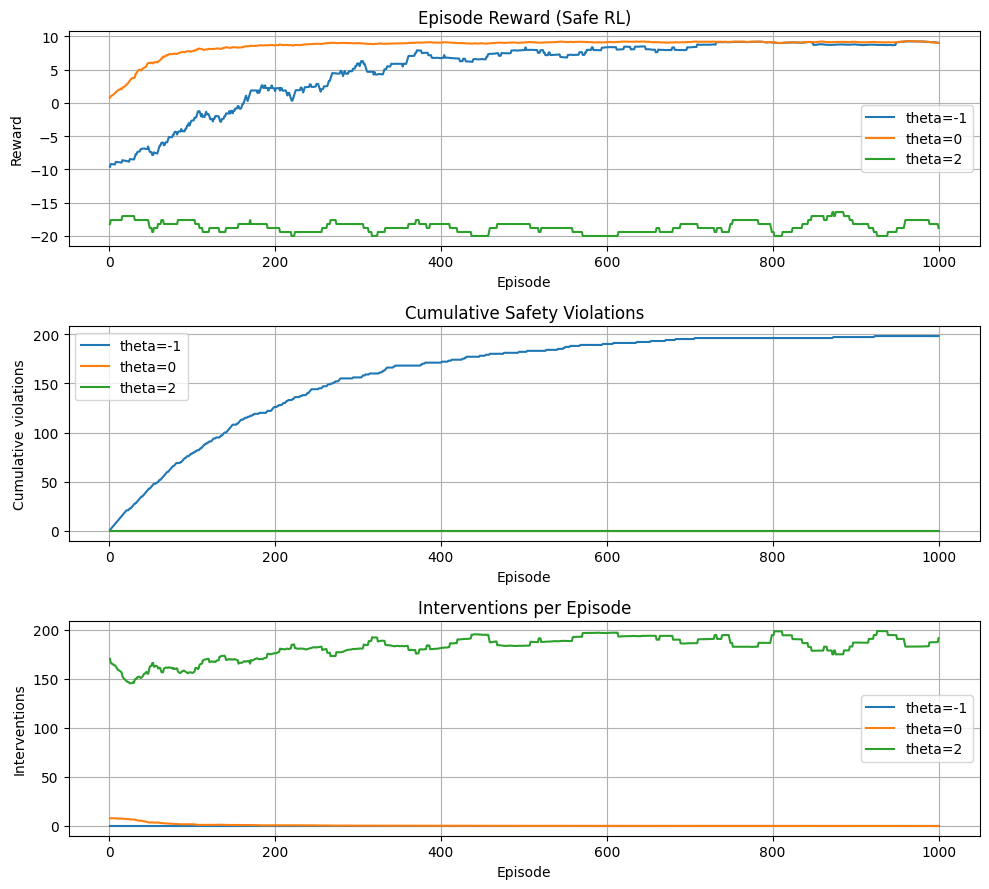

In [ ]:
# ==============================
# Safe RL threshold experiments
# ==============================

# I load the selected baseline Q-table saved from the earlier Q-learning experiment.
def load_best_qtable() -> Dict[Tuple[int, int], np.ndarray]:
    # I use the saved baseline Q-table as the starting policy for Safe RL.
    qpath = DIRS["qtables"] / "baseline_qtable_m0p1.pkl"
    if not qpath.exists():
        raise FileNotFoundError(f"Missing Q-table at {qpath}")
    with open(qpath, "rb") as f:
        obj = pickle.load(f)
    Q_dict = obj["Q"]

    # I convert each Q-value vector to a NumPy array for consistent updates.
    for k in list(Q_dict.keys()):
        Q_dict[k] = np.asarray(Q_dict[k], dtype=float)
    return Q_dict


# I reuse the danger map from memory when available, otherwise I load it from disk.
def load_danger_map() -> Dict[Tuple[int, int], int]:
    if "D_map" in globals():
        return D_map
    dpath = DIRS["data"] / "danger_map.pkl"
    with open(dpath, "rb") as f:
        obj = pickle.load(f)
    return obj["danger_map"]


def compute_safe_metrics(rewards, violations, interventions, episodes):
    # I summarise recent reward behaviour and overall safety/intervention counts.
    M = max(1, int(0.25 * episodes))
    last_rewards = rewards[-M:]
    success_last = [1 if r > 0.0 else 0 for r in last_rewards]
    return {
        "success_rate_last25(%)": 100.0 * (sum(success_last) / float(M)),
        "avg_reward_last25": float(np.mean(last_rewards)),
        "total_violations": int(np.sum(violations)),
        "avg_interventions_per_ep": float(np.mean(interventions)),
    }


def run_safe_experiment(theta: int, episodes: int = 1000, seed: int = 123) -> Dict[str, Any]:
    # I create a random-start environment for shield-guided RL training.
    env = SafeGridWorld(step_penalty=-0.1, random_start=True, seed=seed)
    Q0 = load_best_qtable()
    dmap = load_danger_map()
    shield = ShieldWrapper(shield_model, env, dmap)
    print(f"\nRunning Safe RL with theta={theta} (random_start=True)")

    # I train the Safe RL agent with the selected shield threshold.
    result = train_safe_rl(
        Q_init=Q0, env=env, shield=shield, danger_map=dmap,
        alpha=0.1, gamma=0.99,
        epsilon_start=1.0, epsilon_min=0.01, epsilon_decay=0.995,
        episodes=episodes, max_steps=200, theta=theta, seed=seed
    )

    # I compute summary metrics from the Safe RL training logs.
    metrics = compute_safe_metrics(
        result["rewards"],
        result["violations"],
        result["interventions"],
        episodes
    )
    return {"env": env, "res": result, "met": metrics}


# I compare multiple shield thresholds under the same training setup.
episodes = 1000
exp_none = run_safe_experiment(theta=-1, episodes=episodes, seed=777)
exp_t0  = run_safe_experiment(theta=0,  episodes=episodes, seed=777)
exp_t2  = run_safe_experiment(theta=2,  episodes=episodes, seed=777)

# I organise the Safe RL metrics into a side-by-side comparison table.
comp = pd.DataFrame([
    {"config": "theta=-1 (no shield)", **exp_none["met"]},
    {"config": "theta=0 (lenient)",     **exp_t0["met"]},
    {"config": "theta=2 (strict)",      **exp_t2["met"]},
])
print("\n=== Safe RL comparison (random start) ===")
print(comp.to_string(index=False))

# I plot reward, violation, and intervention trends for each threshold.
fig, axes = plt.subplots(3, 1, figsize=(10, 9))

# I compare smoothed reward curves across threshold settings.
plot_series(exp_none["res"]["rewards"], "Episode Reward (Safe RL)", "Reward",
            label="theta=-1", ax=axes[0], smooth_window=50)
plot_series(exp_t0["res"]["rewards"], "Episode Reward (Safe RL)", "Reward",
            label="theta=0", ax=axes[0], smooth_window=50)
plot_series(exp_t2["res"]["rewards"], "Episode Reward (Safe RL)", "Reward",
            label="theta=2", ax=axes[0], smooth_window=50)

# I compare cumulative safety violations over training.
axes[1].plot(np.arange(1, episodes + 1), np.cumsum(exp_none["res"]["violations"]), label="theta=-1")
axes[1].plot(np.arange(1, episodes + 1), np.cumsum(exp_t0["res"]["violations"]), label="theta=0")
axes[1].plot(np.arange(1, episodes + 1), np.cumsum(exp_t2["res"]["violations"]), label="theta=2")
axes[1].set_title("Cumulative Safety Violations")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Cumulative violations")
axes[1].legend()

# I compare how often the shield changes the proposed action.
plot_series(exp_none["res"]["interventions"], "Interventions per Episode", "Interventions",
            label="theta=-1", ax=axes[2], smooth_window=50)
plot_series(exp_t0["res"]["interventions"], "Interventions per Episode", "Interventions",
            label="theta=0", ax=axes[2], smooth_window=50)
plot_series(exp_t2["res"]["interventions"], "Interventions per Episode", "Interventions",
            label="theta=2", ax=axes[2], smooth_window=50)

plt.tight_layout()
plot_path = save_plot(fig, "safe_rl_threshold_comparison.png")
print("\nSaved plot:", plot_path)
plt.show()

### Persisting Safe RL Logs and Metrics

I save the Safe RL experiment outputs so I can inspect the results later without rerunning the full training process.

For each threshold setting, I export a per-episode log with:

* episode index
* reward
* safety violation count
* shield intervention count

I also save a summary table that compares the Safe RL configurations using the metrics computed in the previous step. This gives me a compact view of reward performance, unsafe events, and intervention frequency across different shield thresholds.

At the end, I print the saved file paths and preview the generated tables. I use these previews as save-checks rather than fixed written conclusions.

In [ ]:
# ==============================
# Persist Safe RL experiment artefacts
# ==============================

# I convert one Safe RL experiment run into a per-episode log file.
def save_episode_logs(exp_obj: Dict[str, Any], tag: str) -> Path:
    rewards = exp_obj["res"]["rewards"]
    violations = exp_obj["res"]["violations"]
    interventions = exp_obj["res"]["interventions"]

    # I store episode-level reward, violation, and intervention records.
    df = pd.DataFrame({
        "episode": np.arange(1, len(rewards) + 1),
        "reward": rewards,
        "violation": violations,
        "intervention": interventions,
    })

    # I save the log table using a tag that identifies the threshold setting.
    out_path = DIRS["reports"] / f"safe_rl_episode_logs_{tag}.csv"
    df.to_csv(out_path, index=False)
    return out_path


# I save per-episode logs for each Safe RL threshold setting.
paths_logs = {}
paths_logs["theta_m1"] = save_episode_logs(exp_none, "theta_m1")
paths_logs["theta_0"]  = save_episode_logs(exp_t0,  "theta_0")
paths_logs["theta_2"]  = save_episode_logs(exp_t2,  "theta_2")

# I build a compact metrics table for comparing the Safe RL configurations.
metrics_df = pd.DataFrame([
    {"config": "theta=-1 (no shield)", **exp_none["met"]},
    {"config": "theta=0 (lenient)",     **exp_t0["met"]},
    {"config": "theta=2 (strict)",      **exp_t2["met"]},
])
metrics_csv_path = DIRS["reports"] / "safe_rl_metrics_summary.csv"
metrics_df.to_csv(metrics_csv_path, index=False)

# I reuse the comparison plot path from the previous cell when available.
try:
    _ = plot_path
except NameError:
    plot_path = DIRS["plots"] / "safe_rl_threshold_comparison.png"

# I print saved log paths to verify that each run was exported.
print("Saved per-episode logs:")
for k, p in paths_logs.items():
    print(f"  {k} -> {p}")

# I print and preview the saved summary metrics table.
print("\nSaved metrics summary to:", metrics_csv_path)
print("\nMetrics summary preview:")
print(metrics_df.to_string(index=False))

# I preview the first rows of each saved episode log.
for tag, p in paths_logs.items():
    df_prev = pd.read_csv(p).head()
    print(f"\nLog preview ({tag}):")
    print(df_prev.to_string(index=False))

# I print the comparison plot path for reference.
print("\nComparison plot path:")
print(plot_path)

Saved per-episode logs:
  theta_m1 -> /content/safe_rl_gridworld/reports/safe_rl_episode_logs_theta_m1.csv
  theta_0 -> /content/safe_rl_gridworld/reports/safe_rl_episode_logs_theta_0.csv
  theta_2 -> /content/safe_rl_gridworld/reports/safe_rl_episode_logs_theta_2.csv

Saved metrics summary to: /content/safe_rl_gridworld/reports/safe_rl_metrics_summary.csv

Metrics summary preview:
              config  success_rate_last25(%)  avg_reward_last25  total_violations  avg_interventions_per_ep
theta=-1 (no shield)                    99.2             8.9828               198                     0.000
   theta=0 (lenient)                   100.0             9.1548                 0                     0.668
    theta=2 (strict)                     6.4           -18.0832                 0                   182.013

Log preview (theta_m1):
 episode  reward  violation  intervention
       1   -10.0          1             0
       2   -10.1          1             0
       3   -10.5          1     

### Exported Artefact Listing and Archive

I inspect the generated project workspace and package the saved artefacts into a ZIP archive.

This gives me a quick check of what the full workflow produced, including:

- datasets
- model files
- Q-tables
- reports
- logs
- metrics
- plots

I first walk through the project folder and print each saved file with its relative path and file size. I use this as a runtime check, since the exact files and sizes can change after rerunning the notebook.

I then create a project archive that preserves the folder structure under the project root. This makes the generated outputs easier to download, inspect, and reuse outside the notebook environment.

At the end, I print the archive path and inspect its top-level contents. If the notebook is running in Colab, I also trigger a download for the generated archive.

In [ ]:
# ==============================
# Export artefact listing and archive
# ==============================

import os
import zipfile

# I print the project workspace so I can inspect all generated artefacts.
print("Project root:", PROJECT_ROOT)
print("\nFile tree (relative paths from project root):")

total_size = 0
for root, dirs, filenames in os.walk(PROJECT_ROOT):
    rel_root = os.path.relpath(root, PROJECT_ROOT)
    for fname in filenames:
        fpath = os.path.join(root, fname)
        rel_path = os.path.join(rel_root, fname) if rel_root != "." else fname
        size_bytes = os.path.getsize(fpath)
        total_size += size_bytes
        print(f"  {rel_path:70s}  {size_bytes / 1024:.1f} KB")

print(f"\nTotal size of project directory: {total_size / 1024:.1f} KB")

# I create a ZIP archive containing the generated project artefacts.
zip_path = PROJECT_ROOT.parent / f"{PROJECT_ROOT.name}_artifacts.zip"
if zip_path.exists():
    zip_path.unlink()

print("\nCreating project archive...")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, filenames in os.walk(PROJECT_ROOT):
        for fname in filenames:
            fpath = os.path.join(root, fname)
            arcname = os.path.relpath(fpath, PROJECT_ROOT)
            zf.write(fpath, arcname=arcname)

zip_size = os.path.getsize(zip_path) / 1024.0
print("Created archive:", zip_path)
print(f"Archive size: {zip_size:.1f} KB")

# I inspect the top-level folders inside the archive as a quick structure check.
print("\nTop-level entries inside the archive:")
with zipfile.ZipFile(zip_path, "r") as zf:
    names = sorted(zf.namelist())
    shown = set()
    for name in names:
        top = name.split("/")[0]
        if top not in shown:
            print("  ", top)
            shown.add(top)

# I trigger a download only when the notebook is running in Colab.
try:
    from google.colab import files
    print("\nStarting download...")
    files.download(str(zip_path))
except ImportError:
    print("\nColab download is not available in this environment.")
    print("Archive path:", zip_path)

Project root: /content/safe_rl_gridworld

File tree (relative paths from project root):
  reports/baseline_episode_logs_m0p1.csv                                  50.3 KB
  reports/safe_rl_episode_logs_theta_0.csv                                13.4 KB
  reports/safety_shield_val_metrics.csv                                   0.1 KB
  reports/safety_shield_loss_curves.csv                                   4.1 KB
  reports/baseline_metrics_summary_m0p1.csv                               0.2 KB
  reports/safe_rl_episode_logs_theta_2.csv                                28.4 KB
  reports/safe_rl_episode_logs_theta_m1.csv                               12.9 KB
  reports/safety_shield_test_metrics.csv                                  0.1 KB
  reports/safe_rl_metrics_summary.csv                                     0.2 KB
  data/complete_dataset.pkl                                               16.3 KB
  data/danger_map.pkl                                                     0.8 KB
  plots/baseline

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Part 7 Summary: Shield-Guided Safe RL Training and Threshold Comparison

In this part, I integrated the trained safety shield into the Q-learning workflow and tested how different shield thresholds affect learning behaviour.

I used the shield as an action filter:

* the Q-learning agent proposes an action
* the shield predicts the danger class for available actions
* unsafe actions are replaced when a safer option is available
* the Q-table is still updated from real environment feedback

I compared three threshold settings under the same random-start training setup:

* no effective filtering
* lenient filtering
* strict filtering

For each setting, I tracked recent success rate, recent average reward, total safety violations, and average interventions per episode. In the current run, the lenient shield setting gives the best balance: it removes unsafe events while keeping reward performance strong and intervention frequency low. The strict setting is safer in terms of violations, but it intervenes too often and hurts learning progress.

I saved the Safe RL logs, summary metrics, comparison plot, and project artefact archive so the outputs can be inspected later without rerunning the full workflow. The exact metric values and file sizes are kept in the generated tables and runtime listing, so this summary stays consistent with future reruns.

## Final Summary: Safe Reinforcement Learning with a Neural Safety Shield

In this notebook, I built an end-to-end safe reinforcement learning workflow around a custom GridWorld environment.

The workflow covers:

* GridWorld environment design and validation
* baseline tabular Q-learning
* danger-map construction with multi-source BFS
* supervised safety-shield dataset generation
* neural safety-shield training and evaluation
* shield-guided Safe RL threshold experiments
* artefact export for models, logs, reports, plots, and Q-tables

### Overall Summary

I started by implementing a custom GridWorld environment with fixed hazards, terminal states, reward rules, reset modes, and visualisation tools. After checking the environment mechanics, I trained a baseline Q-learning agent and compared two step-penalty settings under the same fixed-start setup.

I then built a danger map to describe each cell's distance from the nearest hazard. This gave me a simple safety signal that could be reused later in the notebook.

Using the danger map, I created a supervised dataset of state-action pairs. Each sample includes position, action, next-state, and danger-distance features, with labels grouped into four safety classes.

I trained a compact neural classifier as the safety shield. In this controlled GridWorld setting, the validation and test confusion matrices show that the shield learns the saved safety labels reliably, and the loss curves show stable convergence.

Finally, I integrated the shield into the Q-learning loop. I compared three shield threshold settings and tracked reward, recent success rate, safety violations, and intervention frequency. The current results show a clear safety-performance trade-off: the lenient shield setting gives the best balance, while the strict setting avoids unsafe transitions but intervenes too often and hurts learning progress.

### Key Observations

* Reward design matters: the two baseline step-penalty settings produced different reward trends, success behaviour, and safety-violation patterns.
* The danger map is useful because it turns the grid layout into a reusable safety signal.
* The neural shield works well in this controlled setting, especially because the labels come from a structured danger-distance rule.
* Shield threshold choice is important:

  * too loose → fewer interventions but more unsafe exploration
  * too strict → fewer violations but weaker learning progress
  * lenient filtering → strongest balance in the current run

### Limitations

This project is intentionally small and controlled. The GridWorld setting makes the safety mechanism easy to inspect, but it does not prove that the same approach will scale directly to larger environments.

Some limitations are:

* the environment is small and fully observable
* hazards are fixed rather than dynamic
* the shield relies on engineered danger-map features
* the intervention rule is hand-designed
* the RL agent uses tabular Q-learning, which does not scale well to large state spaces

These choices make the workflow easier to analyse, but they also limit how far the results can be generalised.

### Future Extensions

Useful next steps would include:

* testing larger grids or stochastic transitions
* adding moving hazards or partially observable states
* replacing tabular Q-learning with function approximation
* adding uncertainty estimates to the safety shield
* comparing shield-based intervention with constrained RL or risk-sensitive RL
* penalising unnecessary interventions so the agent learns a better safety-performance balance

### Final Reflection

This project helped me connect several ideas in one workflow: tabular reinforcement learning, graph-based safety analysis, supervised classification, and action-level intervention.

The main takeaway is that a learned safety shield can reduce unsafe exploration, but the threshold design matters. A shield that is too strict can make the agent overly conservative, while a more balanced setting can improve safety without damaging task performance.